# Time Series Forecasting Pipeline
### Data Cleaning → Model Training → Evaluation → Hyperparameter Tuning → MLflow

---

| Step | What happens |
|---|---|
| **1** | Install and import everything we need |
| **2** | Set folder paths |
| **3** | Load and clean the dataset |
| **4** | Train / test split |
| **5** | Define evaluation function |
| **6** | Train all models and evaluate |
| **7** | Compare models and pick the best |
| **8** | Hyperparameter tuning |
| **9** | Save the best model |
| **10** | Log everything to MLflow |

> **Before running:** set `PROJECT_DIR` in Step 2 to your own folder path.

---
## Step 1 — Install and import libraries

Run this cell once to install all required packages.

In [1]:
! pip install pandas numpy matplotlib scikit-learn xgboost statsmodels prophet mlflow joblib -q
print("All packages installed!")

All packages installed!



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os                           # for file handling
import time                         # for time tracking
import warnings                     # to ignore warnings    
import joblib                       # for saving and loading models 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

import mlflow
import mlflow.xgboost

warnings.filterwarnings('ignore')   # to ignore warnings
print("All libraries imported!")

c:\Users\alipa\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


All libraries imported!


---
## Step 2 — Set folder paths

> **Change `PROJECT_DIR` to your own project folder path before running anything else.**

| Variable | Points to |
|---|---|
| `PROJECT_DIR` | Root project folder — where mlruns/, models/, and .txt files are saved |
| `DATA_DIR` | Subfolder where the CSV data files live |

In [3]:
# ── CHANGE THIS to your own project folder ───────────────────
PROJECT_DIR = r'C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series'

# ── Data subfolder (do not change unless your structure is different)
DATA_DIR = os.path.join(PROJECT_DIR, 'data')

# ── MLflow tracking folder
MLFLOW_PATH = os.path.join(PROJECT_DIR, 'mlruns')

# ── Models folder (created automatically later)
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')

# ── Verify paths exist
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:   ", DATA_DIR)
print()
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("DATA_DIR exists:   ", os.path.exists(DATA_DIR))

if not os.path.exists(PROJECT_DIR):
    print()
    print("WARNING: PROJECT_DIR does not exist. Check the path above.")
if not os.path.exists(DATA_DIR):
    print()
    print("WARNING: DATA_DIR does not exist. Check that the data/ subfolder is present.")

PROJECT_DIR: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series
DATA_DIR:    C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\data

PROJECT_DIR exists: True
DATA_DIR exists:    True


---
## Step 3 — Load and clean the dataset

We fix two common problems in time series data:
- **Missing dates** — some days are absent from the dataset
- **Missing values** — a date exists but the sales value is blank

In [4]:
# ── Load the dataset ─────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'timeseries_with_features.csv'))
df['date'] = pd.to_datetime(df['date'])                                         # ensure 'date' is datetime type
df = df.sort_values('date').reset_index(drop=True)

print("Dataset loaded!")
print("Shape:", df.shape)
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())    # check date range

Dataset loaded!
Shape: (452, 25)
Date range: 2013-01-02 to 2014-03-31


In [5]:
# ── Check for missing dates ───────────────────────────────────
full_date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D') # create complete date range
missing_dates   = full_date_range.difference(df['date'])                                # find missing dates

print("Expected dates:", len(full_date_range))
print("Dates we have: ", len(df))
print("Missing dates: ", len(missing_dates))

Expected dates: 454
Dates we have:  452
Missing dates:  2


In [6]:
# ── Fill missing dates and values ────────────────────────────
df = df.set_index('date')
df = df.reindex(full_date_range)
df.index.name = 'date'

# Linear interpolation fills gaps smoothly
df['unit_sales'] = df['unit_sales'].interpolate(method='linear')                        # interpolate 'unit_sales' column

# Forward fill then backward fill for any remaining NaNs
df = df.ffill().bfill()                                                                 # fill remaining NaNs with forward fill, then backward fill

print("After cleaning:")
print("Total rows:", len(df))
print("Remaining NaNs:", df.isnull().sum().sum())
print("All clean!" if df.isnull().sum().sum() == 0 else "Some NaNs remain.")

After cleaning:
Total rows: 454
Remaining NaNs: 0
All clean!


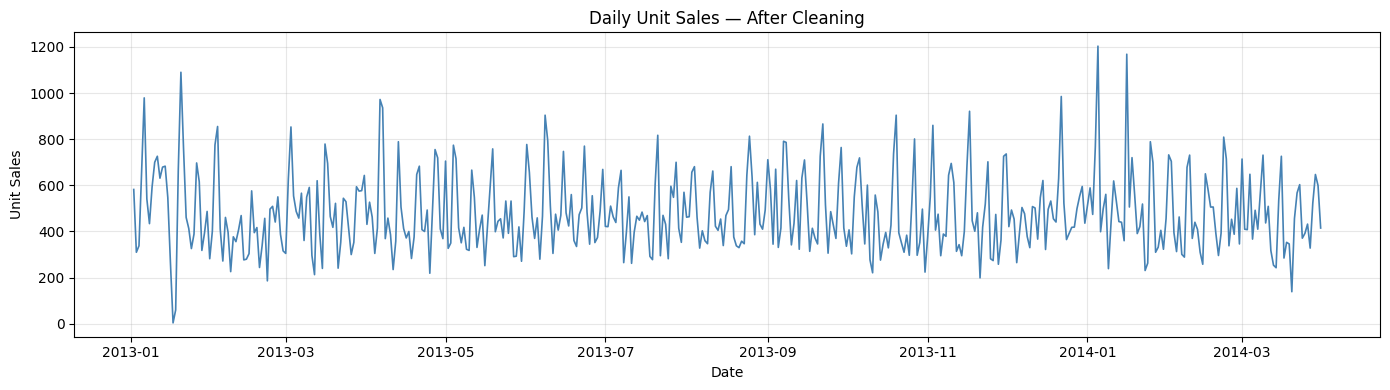

In [7]:
#  ── Quick visual check ───────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['unit_sales'], color='steelblue', linewidth=1.2)
plt.title('Daily Unit Sales — After Cleaning')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4 — Train / test split

We split by time — the model always trains on the past and tests on the future.

- **Training:** January 2013 – December 2013
- **Test:** January 2014 – March 2014

In [8]:
SPLIT_DATE = '2014-01-01'

df_train = df.loc[df.index < SPLIT_DATE].copy()     # training set is all data before the split date
df_test  = df.loc[df.index >= SPLIT_DATE].copy()    # test set is all data from the split date onward

print("Training rows:", len(df_train), " |", df_train.index.min().date(), "to", df_train.index.max().date())
print("Test rows:    ", len(df_test),  " |", df_test.index.min().date(),  "to", df_test.index.max().date()) 

Training rows: 364  | 2013-01-02 to 2013-12-31
Test rows:     90  | 2014-01-01 to 2014-03-31


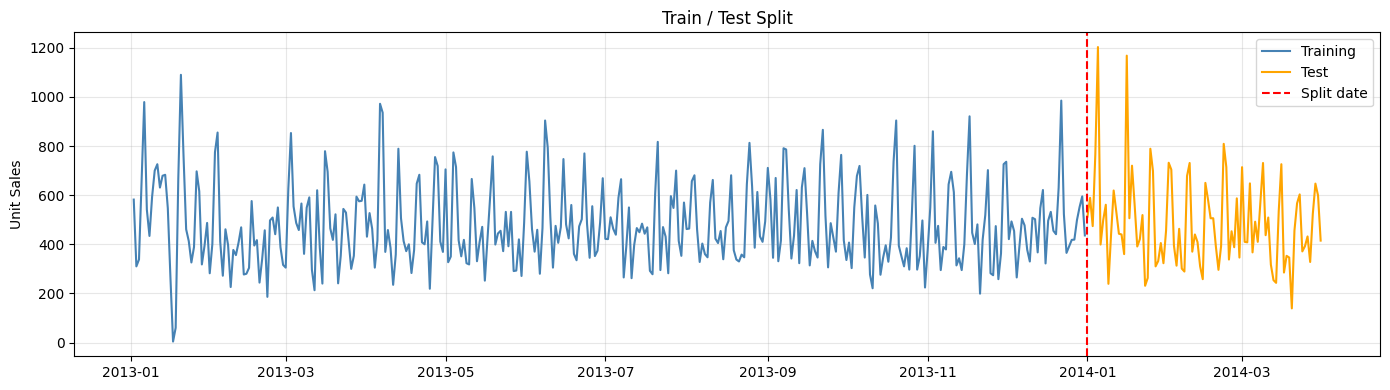

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(df_train.index, df_train['unit_sales'], label='Training', color='steelblue')
plt.plot(df_test.index,  df_test['unit_sales'],  label='Test',     color='orange')
plt.axvline(pd.to_datetime(SPLIT_DATE), color='red', linestyle='--', label='Split date')
plt.title('Train / Test Split')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 5 — Evaluation function

One reusable function calculates all metrics for every model.

| Metric | What it tells you | Target |
|---|---|---|
| MAE | Average error in sales units | As low as possible |
| RMSE | Same as MAE but large errors count more | As low as possible |
| MAPE | Error as a % of actual sales | < 20% strong |
| Bias | Are we always too high or too low? | As close to 0 as possible |
| R² | How much variation does the model explain? | Closer to 1.0 |
| Training time | How long did the model take to fit? | Practical constraint |

In [10]:
def evaluate_model(name, actual, predicted, training_time=None):    # define a function to evaluate model performance
    """
    Calculates all evaluation metrics for one model.
    Returns a dictionary so results can be stored and compared.
    """
    actual    = np.array(actual)
    predicted = np.array(predicted)

    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    bias = np.mean(predicted - actual)
    r2   = r2_score(actual, predicted)

    # MAPE: skip zeros to avoid division by zero
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    print(f"── {name} {'─' * max(1, 42 - len(name))}")
    print(f"  MAE:           {mae:.2f}")
    print(f"  RMSE:          {rmse:.2f}")
    print(f"  MAPE:          {mape:.1f}%")
    print(f"  Bias:          {bias:+.2f}  ({'over-predicting' if bias > 0 else 'under-predicting'})")
    print(f"  R²:            {r2:.3f}")
    if training_time is not None:
        t = f"{training_time:.1f}s" if training_time < 60 else f"{training_time/60:.1f}m"   # format time in seconds or minutes
        print(f"  Training time: {t}")
    print()

    return {
        'model':           name,                                                    # model name for reference
        'MAE':             round(mae,  2),                                          # round MAE to 2 decimal places
        'RMSE':            round(rmse, 2),                                          # round RMSE to 2 decimal places              
        'MAPE':            round(mape, 1),                                          # round MAPE to 1 decimal place and add % in print statement      
        'Bias':            round(bias, 2),                                          # round bias to 2 decimal places
        'R2':              round(r2,   3),                                          # round R² to 3 decimal places
        'Training_time_s': round(training_time, 1) if training_time else None       # round training time to 1 decimal place, or None if not provided
    }

print("evaluate_model() defined.")

evaluate_model() defined.


In [11]:
# Results list — collects one dictionary per model

results = []
print("results list ready.")

results list ready.


---
## Step 6 — Define features and train all models

ARIMA and Holt-Winters use only `unit_sales`.
XGBoost and LSTM use the engineered feature columns.

In [12]:
# ── Feature columns (same as Feature Engineering notebook) ──
FEATURES = [
    'year', 'month', 'day', 'dayofweek', 'quarter', 'week_of_year',
    'is_weekend', 'is_month_start', 'is_month_end',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std',
    'dcoilwtico', 'oil_lag_1', 'oil_rolling_7d_mean',
    'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',
]
TARGET = 'unit_sales'

X_train = df_train[FEATURES]    # feature columns for training
y_train = df_train[TARGET]      # target column for training
X_test  = df_test[FEATURES]     # feature columns for testing
y_test  = df_test[TARGET]       # target column for testing

print("Features:", len(FEATURES))
print("Training samples:", len(X_train))
print("Test samples:    ", len(X_test))

Features: 23
Training samples: 364
Test samples:     90


---
### Model 1 — ARIMA / SARIMAX

In [13]:
train_sales = df_train['unit_sales']        # target variable for training
test_sales  = df_test['unit_sales']         # target variable for testing

start = time.time()
arima_model = SARIMAX(train_sales, order=(1,1,1), seasonal_order=(1,1,1,7)) # simple SARIMA with weekly seasonality
arima_fit   = arima_model.fit(disp=False)                                   # fit the model (disp=False to suppress output)
arima_preds = arima_fit.forecast(steps=len(test_sales))                     # forecast for the test period
arima_time  = time.time() - start                                           # time taken to train and forecast

arima_result = evaluate_model("ARIMA", test_sales.values, arima_preds.values, arima_time)
results.append(arima_result)    # store results for comparison

── ARIMA ─────────────────────────────────────
  MAE:           95.65
  RMSE:          143.68
  MAPE:          21.2%
  Bias:          -9.29  (under-predicting)
  R²:            0.386
  Training time: 0.5s



---
### Model 2 — Holt-Winters

In [14]:
start   = time.time()
hw_model = ExponentialSmoothing(train_sales, trend='add', seasonal='add', seasonal_periods=7)   # Holt-Winters with additive trend and seasonality, weekly seasonality
hw_fit   = hw_model.fit()                       # fit the model
hw_preds = hw_fit.forecast(len(test_sales))     # forecast for the test period
hw_time  = time.time() - start

hw_result = evaluate_model("Holt-Winters", test_sales.values, hw_preds.values, hw_time)         # evaluate and store results
results.append(hw_result)

── Holt-Winters ──────────────────────────────
  MAE:           94.83
  RMSE:          143.07
  MAPE:          21.0%
  Bias:          -9.12  (under-predicting)
  R²:            0.392
  Training time: 0.1s



---
### Model 3 — Prophet

In [15]:
prophet_train = df_train[['unit_sales']].reset_index().rename(columns={'date':'ds','unit_sales':'y'})   # Prophet requires a DataFrame with 'ds' for date and 'y' for target variable
prophet_test  = df_test[['unit_sales']].reset_index().rename(columns={'date':'ds','unit_sales':'y'})    # same for test set

start         = time.time()
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)                               # Prophet with weekly and yearly seasonality (daily data often has both)
prophet_model.fit(prophet_train)                                                                      
future        = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='D')                # create future dataframe for the test period
prophet_fore  = prophet_model.predict(future)                                                           # predict for the future dates (which includes the test period)
prophet_preds = prophet_fore.set_index('ds')['yhat'].loc[prophet_test['ds']]                            # extract predictions for the test period by matching dates
prophet_time  = time.time() - start

prophet_result = evaluate_model("Prophet", prophet_test['y'].values, prophet_preds.values, prophet_time)    # evaluate and store results
results.append(prophet_result)

16:22:37 - cmdstanpy - INFO - Chain [1] start processing
16:22:37 - cmdstanpy - INFO - Chain [1] done processing


── Prophet ───────────────────────────────────
  MAE:           156.53
  RMSE:          201.94
  MAPE:          30.9%
  Bias:          -144.59  (under-predicting)
  R²:            -0.212
  Training time: 0.3s



---
### Model 4 — XGBoost (baseline)

In [16]:
start     = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0)   # simple XGBoost with some basic hyperparameters (can be tuned further)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)                                     # fit the model (verbose=False to suppress training output)
xgb_preds = xgb_model.predict(X_test)                                                                           # predict for the test set
xgb_time  = time.time() - start

xgb_result = evaluate_model("XGBoost (baseline)", y_test.values, xgb_preds, xgb_time)                           # evaluate and store results
results.append(xgb_result)

── XGBoost (baseline) ────────────────────────
  MAE:           108.60
  RMSE:          155.72
  MAPE:          24.8%
  Bias:          +5.53  (over-predicting)
  R²:            0.279
  Training time: 0.2s



---
### Model 5 — LSTM (Optional)

> LSTM training takes 5–15 minutes. This cell is fully commented out.
> Uncomment and run only if you want to include it in the comparison.

In [17]:
# ── LSTM (OPTIONAL) ─────────────────────────────────────────
# Uncomment all lines below to run LSTM

from sklearn.preprocessing import MinMaxScaler
import torch, torch.nn as nn

LOOK_BACK   = 7
scaler      = MinMaxScaler()
sales_scaled = scaler.fit_transform(df[['unit_sales']]).flatten()

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(sales_scaled, LOOK_BACK)
split_idx    = len(df_train) - LOOK_BACK
X_tr, y_tr   = X_seq[:split_idx], y_seq[:split_idx]
X_te, y_te   = X_seq[split_idx:], y_seq[split_idx:]

X_tr_t = torch.FloatTensor(X_tr).unsqueeze(-1)
y_tr_t = torch.FloatTensor(y_tr).unsqueeze(-1)
X_te_t = torch.FloatTensor(X_te).unsqueeze(-1)

class SimpleLSTM(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.lstm   = nn.LSTM(1, hidden, batch_first=True)
        self.linear = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])

lstm_model = SimpleLSTM(hidden=64)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn    = nn.MSELoss()

start = time.time()
for epoch in range(30):
    lstm_model.train()
    optimizer.zero_grad()
    preds = lstm_model(X_tr_t)
    loss  = loss_fn(preds, y_tr_t)
    loss.backward()
    optimizer.step()
lstm_time = time.time() - start

lstm_model.eval()
with torch.no_grad():
    lstm_raw = lstm_model(X_te_t).numpy().flatten()
lstm_preds_inv = scaler.inverse_transform(lstm_raw.reshape(-1,1)).flatten()

lstm_result = evaluate_model("LSTM", y_test.values[-len(lstm_preds_inv):], lstm_preds_inv, lstm_time)
results.append(lstm_result)

print("LSTM is commented out. Uncomment above to run.")

── LSTM ──────────────────────────────────────
  MAE:           140.88
  RMSE:          183.94
  MAPE:          32.8%
  Bias:          -4.63  (under-predicting)
  R²:            -0.006
  Training time: 0.1s

LSTM is commented out. Uncomment above to run.


---
## Step 7 — Compare all models

In [18]:
df_results = pd.DataFrame(results).set_index('model')                                           # create a DataFrame from the results list and set 'model' as the index

print("Model Comparison Table")
print("=" * 60)
print(df_results[['MAE','RMSE','MAPE','Bias','R2','Training_time_s']].round(2).to_string())     # print the results table with selected columns
print()
print("Best by MAE: ", df_results['MAE'].idxmin())
print("Best by RMSE:", df_results['RMSE'].idxmin())
print("Best by MAPE:  ", df_results['MAPE'].idxmin())

Model Comparison Table
                       MAE    RMSE  MAPE    Bias    R2  Training_time_s
model                                                                  
ARIMA                95.65  143.68  21.2   -9.29  0.39              0.5
Holt-Winters         94.83  143.07  21.0   -9.12  0.39              0.1
Prophet             156.53  201.94  30.9 -144.59 -0.21              0.3
XGBoost (baseline)  108.60  155.72  24.8    5.53  0.28              0.2
LSTM                140.88  183.94  32.8   -4.63 -0.01              0.1

Best by MAE:  Holt-Winters
Best by RMSE: Holt-Winters
Best by MAPE:   Holt-Winters


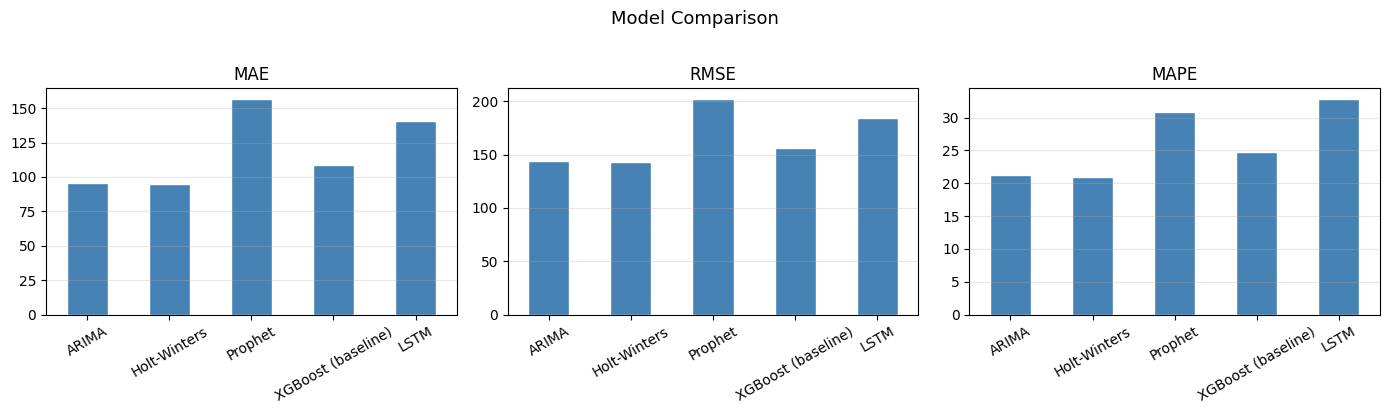

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    df_results[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle('Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# ── Pick the best model by MAE ────────────────────────────────
# Change 'MAE' to 'RMSE' or 'R2' if you prefer a different metric
best_model_name = df_results['MAE'].idxmin()   

print(f"Best model:  {best_model_name}")
print(f"MAE:         {df_results.loc[best_model_name, 'MAE']}")
print(f"RMSE:        {df_results.loc[best_model_name, 'RMSE']}")
print(f"MAPE:        {df_results.loc[best_model_name, 'MAPE']}%")
print(f"Bias:        {df_results.loc[best_model_name, 'Bias']:+.2f}")
print(f"R²:          {df_results.loc[best_model_name, 'R2']}")

Best model:  Holt-Winters
MAE:         94.83
RMSE:        143.07
MAPE:        21.0%
Bias:        -9.12
R²:          0.392


---
## Step 8 — Hyperparameter tuning (XGBoost)

We search for the best combination of settings using `RandomizedSearchCV`.
`TimeSeriesSplit` ensures we always train on the past and validate on the future.

| Parameter | What it controls |
|---|---|
| `n_estimators` | Number of trees to build |
| `max_depth` | How deep each tree can grow |
| `learning_rate` | How much each tree contributes |
| `subsample` | Fraction of data each tree sees |

In [21]:
param_grid = {
    'n_estimators':  [100, 300, 500],       # number of trees in the ensemble
    'max_depth':     [3, 4, 5, 6],          # maximum depth of each tree (controls complexity)
    'learning_rate': [0.01, 0.05, 0.1],     # learning rate (how much each tree contributes to the final prediction)
    'subsample':     [0.7, 0.8, 1.0],       # subsample ratio of the training instances (helps prevent overfitting)
}

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(                # use RandomizedSearchCV for faster tuning
    estimator           = xgb.XGBRegressor(verbosity=0, random_state=42),
    param_distributions = param_grid,
    n_iter              = 20,
    scoring             = 'neg_mean_absolute_error',
    cv                  = tscv,
    random_state        = 42,
    n_jobs              = -1
)

print("Starting search — this may take 1–2 minutes...")
search.fit(X_train, y_train)                # perform the hyperparameter search using the training data

print()
print("Best parameters found:")
for param, value in search.best_params_.items():    # print each best parameter and its value
    print(f"  {param}: {value}")

Starting search — this may take 1–2 minutes...

Best parameters found:
  subsample: 0.8
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.01


In [22]:
best_xgb    = search.best_estimator_                # get the best model from the search
tuned_preds = best_xgb.predict(X_test)              # predict for the test set using the tuned model

tuned_result = evaluate_model("XGBoost (tuned)", y_test.values, tuned_preds)        # evaluate and store results
results.append(tuned_result)

baseline_mae = df_results.loc['XGBoost (baseline)', 'MAE']
print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Tuned MAE:    {tuned_result['MAE']:.2f}")
print(f"Improvement:  {baseline_mae - tuned_result['MAE']:.2f} units")

── XGBoost (tuned) ───────────────────────────
  MAE:           96.30
  RMSE:          141.45
  MAPE:          22.0%
  Bias:          -2.19  (under-predicting)
  R²:            0.405

Baseline MAE: 108.60
Tuned MAE:    96.30
Improvement:  12.30 units


---
## Step 8b — Hyperopt Tuning (All Models)

We apply **Hyperopt Bayesian TPE** to every model in the pipeline —  
not just XGBoost, but also ARIMA, Holt-Winters, Prophet, and LSTM.

Each model uses the **last 30 days of training** as a held-out validation window  
to score each trial without touching the test set.

| Model | Search space | Trials | Est. time |
|---|---|---|---|
| ARIMA | p, d, q | 15 | ~1 min |
| Holt-Winters | trend type, damped_trend | 15 | <10 s |
| Prophet | changepoint_prior, seasonality_prior, mode | 15 | ~30 s |
| XGBoost | n_estimators, max_depth, lr, subsample, colsample | 30 | ~30 s |
| LSTM | hidden_size, learning_rate, batch_size | 10 | ~2 min |

In [23]:
# ── Hyperopt setup ────────────────────────────────────────────
! pip install hyperopt -q

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from torch.utils.data import DataLoader, TensorDataset

# Validation window — last 30 days of training used to score every trial
VAL_WINDOW = 30
train_val  = train_sales.iloc[:-VAL_WINDOW]   # 334 rows used to fit inside each trial
val_sales  = train_sales.iloc[-VAL_WINDOW:]   # 30 rows used to measure trial error

print("Hyperopt ready.")
print(f"Validation window : {VAL_WINDOW} days")
print(f"  Fit subset  : {train_val.index[0].date()} → {train_val.index[-1].date()}  ({len(train_val)} rows)")
print(f"  Score subset: {val_sales.index[0].date()} → {val_sales.index[-1].date()}  ({len(val_sales)} rows)")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Hyperopt ready.
Validation window : 30 days
  Fit subset  : 2013-01-02 → 2013-12-01  (334 rows)
  Score subset: 2013-12-02 → 2013-12-31  (30 rows)


---
### Hyperopt — ARIMA

Search the non-seasonal orders `(p, d, q)`.  
Seasonal order is fixed at `(1, 1, 1, 7)` since weekly seasonality is already known.

In [24]:
# ── Hyperopt for ARIMA ────────────────────────────────────────
_p_vals = [0, 1, 2, 3]
_d_vals = [0, 1]
_q_vals = [0, 1, 2, 3]

def arima_objective(params):
    p, d, q = _p_vals[params['p']], _d_vals[params['d']], _q_vals[params['q']]
    try:
        mdl  = SARIMAX(train_val, order=(p, d, q), seasonal_order=(1, 1, 1, 7))
        fit  = mdl.fit(disp=False)
        pred = fit.forecast(steps=VAL_WINDOW)
        mae  = mean_absolute_error(val_sales.values, pred.values)
        return {'loss': mae, 'status': STATUS_OK}
    except Exception:
        return {'loss': 1e6, 'status': STATUS_OK}

arima_space = {
    'p': hp.choice('arima_p', list(range(len(_p_vals)))),
    'd': hp.choice('arima_d', list(range(len(_d_vals)))),
    'q': hp.choice('arima_q', list(range(len(_q_vals)))),
}

print("Tuning ARIMA with Hyperopt (15 trials) — may take ~1 min ...")
arima_hyp_trials = Trials()
arima_best       = fmin(fn=arima_objective, space=arima_space, algo=tpe.suggest,
                        max_evals=15, trials=arima_hyp_trials,
                        rstate=np.random.default_rng(42), verbose=False)

best_p = _p_vals[arima_best['arima_p']]
best_d = _d_vals[arima_best['arima_d']]
best_q = _q_vals[arima_best['arima_q']]
print(f"Best ARIMA order: ({best_p}, {best_d}, {best_q})")

# Retrain on full training data
arima_tuned_fit   = SARIMAX(train_sales, order=(best_p, best_d, best_q),
                             seasonal_order=(1, 1, 1, 7)).fit(disp=False)
arima_tuned_preds = arima_tuned_fit.forecast(steps=len(test_sales))
arima_tuned_result = evaluate_model("ARIMA (Hyperopt)",
                                     test_sales.values, arima_tuned_preds.values)
results.append(arima_tuned_result)

Tuning ARIMA with Hyperopt (15 trials) — may take ~1 min ...
Best ARIMA order: (1, 0, 2)
── ARIMA (Hyperopt) ──────────────────────────
  MAE:           94.81
  RMSE:          142.67
  MAPE:          21.1%
  Bias:          -6.90  (under-predicting)
  R²:            0.395



---
### Hyperopt — Holt-Winters

Search over `trend` type (additive, multiplicative, or none) and `damped_trend`.  
Seasonal component is fixed at additive with period 7 (weekly).

In [25]:
# ── Hyperopt for Holt-Winters ─────────────────────────────────
_trend_vals = ['add', 'mul', None]

def hw_objective(params):
    trend  = _trend_vals[params['trend']]
    damped = bool(params['damped_trend'])
    try:
        mdl  = ExponentialSmoothing(
            train_val, trend=trend, seasonal='add', seasonal_periods=7,
            damped_trend=damped if trend is not None else False
        )
        fit  = mdl.fit(optimized=True)
        pred = fit.forecast(VAL_WINDOW)
        mae  = mean_absolute_error(val_sales.values, pred.values)
        return {'loss': mae, 'status': STATUS_OK}
    except Exception:
        return {'loss': 1e6, 'status': STATUS_OK}

hw_space = {
    'trend':        hp.choice('hw_trend',  list(range(len(_trend_vals)))),
    'damped_trend': hp.choice('hw_damped', [0, 1]),
}

print("Tuning Holt-Winters with Hyperopt (15 trials) ...")
hw_hyp_trials = Trials()
hw_best       = fmin(fn=hw_objective, space=hw_space, algo=tpe.suggest,
                     max_evals=15, trials=hw_hyp_trials,
                     rstate=np.random.default_rng(42), verbose=False)

best_trend  = _trend_vals[hw_best['hw_trend']]
best_damped = bool(hw_best['hw_damped'])
print(f"Best HW params: trend={best_trend}, damped_trend={best_damped}")

# Retrain on full training data
hw_tuned_fit   = ExponentialSmoothing(
    train_sales, trend=best_trend, seasonal='add', seasonal_periods=7,
    damped_trend=best_damped if best_trend is not None else False
).fit(optimized=True)
hw_tuned_preds = hw_tuned_fit.forecast(len(test_sales))
hw_tuned_result = evaluate_model("Holt-Winters (Hyperopt)",
                                  test_sales.values, hw_tuned_preds.values)
results.append(hw_tuned_result)

Tuning Holt-Winters with Hyperopt (15 trials) ...
Best HW params: trend=add, damped_trend=False
── Holt-Winters (Hyperopt) ───────────────────
  MAE:           94.83
  RMSE:          143.07
  MAPE:          21.0%
  Bias:          -9.12  (under-predicting)
  R²:            0.392



---
### Hyperopt — Prophet

Tune `changepoint_prior_scale` (trend flexibility), `seasonality_prior_scale` (seasonal flexibility),  
and `seasonality_mode` (additive vs multiplicative).

In [26]:
# ── Hyperopt for Prophet ──────────────────────────────────────
_prophet_mode = ['additive', 'multiplicative']

_prophet_train_val = prophet_train.iloc[:-VAL_WINDOW].copy()
_prophet_val       = prophet_train.iloc[-VAL_WINDOW:].copy()

def prophet_objective(params):
    try:
        m = Prophet(
            changepoint_prior_scale = params['changepoint_prior_scale'],
            seasonality_prior_scale = params['seasonality_prior_scale'],
            seasonality_mode        = _prophet_mode[params['seasonality_mode']],
            weekly_seasonality=True, yearly_seasonality=True
        )
        m.fit(_prophet_train_val)
        future = m.make_future_dataframe(periods=VAL_WINDOW, freq='D')
        fc     = m.predict(future)
        pred   = fc.set_index('ds')['yhat'].loc[_prophet_val['ds']].values
        mae    = mean_absolute_error(_prophet_val['y'].values, pred)
        return {'loss': mae, 'status': STATUS_OK}
    except Exception:
        return {'loss': 1e6, 'status': STATUS_OK}

prophet_space = {
    'changepoint_prior_scale': hp.loguniform('cps', np.log(0.001), np.log(0.5)),
    'seasonality_prior_scale': hp.loguniform('sps', np.log(0.01),  np.log(10.0)),
    'seasonality_mode':        hp.choice('smode', [0, 1]),
}

print("Tuning Prophet with Hyperopt (15 trials) ...")
prophet_hyp_trials = Trials()
prophet_best       = fmin(fn=prophet_objective, space=prophet_space, algo=tpe.suggest,
                          max_evals=15, trials=prophet_hyp_trials,
                          rstate=np.random.default_rng(42), verbose=False)

best_cps   = prophet_best['cps']
best_sps   = prophet_best['sps']
best_smode = _prophet_mode[prophet_best['smode']]
print(f"Best Prophet params: changepoint_prior={best_cps:.4f}, "
      f"seasonality_prior={best_sps:.4f}, mode={best_smode}")

# Retrain on full training data
prophet_tuned_model = Prophet(
    changepoint_prior_scale=best_cps,
    seasonality_prior_scale=best_sps,
    seasonality_mode=best_smode,
    weekly_seasonality=True, yearly_seasonality=True
)
prophet_tuned_model.fit(prophet_train)
_future_tuned       = prophet_tuned_model.make_future_dataframe(
                          periods=len(prophet_test), freq='D')
_fc_tuned           = prophet_tuned_model.predict(_future_tuned)
prophet_tuned_preds = _fc_tuned.set_index('ds')['yhat'].loc[prophet_test['ds']].values
prophet_tuned_result = evaluate_model("Prophet (Hyperopt)",
                                       prophet_test['y'].values, prophet_tuned_preds)
results.append(prophet_tuned_result)

16:23:00 - cmdstanpy - INFO - Chain [1] start processing


Tuning Prophet with Hyperopt (15 trials) ...


16:23:01 - cmdstanpy - INFO - Chain [1] done processing
16:23:01 - cmdstanpy - INFO - Chain [1] start processing
16:23:01 - cmdstanpy - INFO - Chain [1] done processing
16:23:01 - cmdstanpy - INFO - Chain [1] start processing
16:23:01 - cmdstanpy - INFO - Chain [1] done processing
16:23:01 - cmdstanpy - INFO - Chain [1] start processing
16:23:01 - cmdstanpy - INFO - Chain [1] done processing
16:23:01 - cmdstanpy - INFO - Chain [1] start processing
16:23:01 - cmdstanpy - INFO - Chain [1] done processing
16:23:02 - cmdstanpy - INFO - Chain [1] start processing
16:23:02 - cmdstanpy - INFO - Chain [1] done processing
16:23:02 - cmdstanpy - INFO - Chain [1] start processing
16:23:02 - cmdstanpy - INFO - Chain [1] done processing
16:23:02 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:23:02 - cmdstanpy - INFO - Chain [1] start processing
16:23:02 - cmdstanpy - INFO - Chain [1] done processing
16:23:03 - c

Best Prophet params: changepoint_prior=0.0017, seasonality_prior=0.0159, mode=multiplicative
── Prophet (Hyperopt) ────────────────────────
  MAE:           127.86
  RMSE:          182.61
  MAPE:          24.9%
  Bias:          -80.26  (under-predicting)
  R²:            0.009



---
### Hyperopt — XGBoost

Replaces the `RandomizedSearchCV` above with Bayesian search.  
Adds `colsample_bytree` to the search space and uses continuous ranges for `learning_rate` and `subsample`.  
Uses `TimeSeriesSplit` (3 folds) to keep the temporal order intact.

In [27]:
# ── Hyperopt for XGBoost ──────────────────────────────────────
_n_est_vals = [100, 200, 300, 500]
_depth_vals = [3, 4, 5, 6]

def xgb_objective(params):
    mdl = xgb.XGBRegressor(
        n_estimators     = _n_est_vals[params['n_estimators']],
        max_depth        = _depth_vals[params['max_depth']],
        learning_rate    = params['learning_rate'],
        subsample        = params['subsample'],
        colsample_bytree = params['colsample_bytree'],
        verbosity=0, random_state=42
    )
    tscv_ = TimeSeriesSplit(n_splits=3)
    maes  = []
    for tr_idx, val_idx in tscv_.split(X_train):
        mdl.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        pred = mdl.predict(X_train.iloc[val_idx])
        maes.append(mean_absolute_error(y_train.iloc[val_idx], pred))
    return {'loss': np.mean(maes), 'status': STATUS_OK}

xgb_space = {
    'n_estimators':     hp.choice('xgb_n_est',  list(range(len(_n_est_vals)))),
    'max_depth':        hp.choice('xgb_depth',  list(range(len(_depth_vals)))),
    'learning_rate':    hp.loguniform('xgb_lr',        np.log(0.01), np.log(0.2)),
    'subsample':        hp.uniform('xgb_sub',          0.6, 1.0),
    'colsample_bytree': hp.uniform('xgb_col',          0.6, 1.0),
}

print("Tuning XGBoost with Hyperopt (30 trials) ...")
xgb_hyp_trials = Trials()
xgb_best       = fmin(fn=xgb_objective, space=xgb_space, algo=tpe.suggest,
                      max_evals=30, trials=xgb_hyp_trials,
                      rstate=np.random.default_rng(42), verbose=False)

best_xgb_hyperopt = xgb.XGBRegressor(
    n_estimators     = _n_est_vals[xgb_best['xgb_n_est']],
    max_depth        = _depth_vals[xgb_best['xgb_depth']],
    learning_rate    = xgb_best['xgb_lr'],
    subsample        = xgb_best['xgb_sub'],
    colsample_bytree = xgb_best['xgb_col'],
    verbosity=0, random_state=42
)
best_xgb_hyperopt.fit(X_train, y_train)
xgb_hyp_preds  = best_xgb_hyperopt.predict(X_test)
xgb_hyp_result = evaluate_model("XGBoost (Hyperopt)", y_test.values, xgb_hyp_preds)
results.append(xgb_hyp_result)

print(f"Best XGBoost params:")
print(f"  n_estimators:     {_n_est_vals[xgb_best['xgb_n_est']]}")
print(f"  max_depth:        {_depth_vals[xgb_best['xgb_depth']]}")
print(f"  learning_rate:    {xgb_best['xgb_lr']:.4f}")
print(f"  subsample:        {xgb_best['xgb_sub']:.3f}")
print(f"  colsample_bytree: {xgb_best['xgb_col']:.3f}")

Tuning XGBoost with Hyperopt (30 trials) ...
── XGBoost (Hyperopt) ────────────────────────
  MAE:           96.42
  RMSE:          143.88
  MAPE:          21.9%
  Bias:          -1.96  (under-predicting)
  R²:            0.385

Best XGBoost params:
  n_estimators:     300
  max_depth:        4
  learning_rate:    0.0112
  subsample:        0.994
  colsample_bytree: 0.602


---
### Hyperopt — LSTM

Tune `hidden_size`, `learning_rate`, and `batch_size`.  
Each trial trains for up to 80 epochs with early stopping (patience = 10).

> **Depends on:** `SimpleLSTM`, `X_tr_t`, `y_tr_t`, `X_te_t`, `scaler` — all defined in Model 5 above.

In [28]:
# ── Hyperopt for LSTM ─────────────────────────────────────────
# Uses SimpleLSTM, X_tr_t, y_tr_t, X_te_t, scaler defined in Model 5 above

_lstm_val_split = len(X_tr) - VAL_WINDOW

_X_tr_inner  = X_tr_t[:_lstm_val_split]    # (m, 7, 1)
_y_tr_inner  = y_tr_t[:_lstm_val_split]    # (m, 1)
_X_val_inner = X_tr_t[_lstm_val_split:]    # (VAL_WINDOW, 7, 1)
_y_val_inner = y_tr_t[_lstm_val_split:]    # (VAL_WINDOW, 1)

_hidden_vals = [32, 64, 128]
_batch_vals  = [8, 16, 32]
_mse         = nn.MSELoss()

def lstm_objective(params):
    hidden     = _hidden_vals[params['hidden']]
    lr         = params['lr']
    batch_size = _batch_vals[params['batch_size']]

    mdl      = SimpleLSTM(hidden=hidden)
    opt      = torch.optim.Adam(mdl.parameters(), lr=lr)
    loader   = DataLoader(TensorDataset(_X_tr_inner, _y_tr_inner),
                          batch_size=batch_size, shuffle=False)
    best_val  = float('inf')
    patience_ = 0

    for epoch in range(80):
        mdl.train()
        for xb, yb in loader:
            opt.zero_grad()
            _mse(mdl(xb), yb).backward()
            opt.step()
        mdl.eval()
        with torch.no_grad():
            val_loss = _mse(mdl(_X_val_inner), _y_val_inner).item()
        if val_loss < best_val:
            best_val  = val_loss
            patience_ = 0
        else:
            patience_ += 1
        if patience_ >= 10:
            break

    return {'loss': best_val, 'status': STATUS_OK}

lstm_space = {
    'hidden':     hp.choice('hidden',     list(range(len(_hidden_vals)))),
    'lr':         hp.loguniform('lr',     np.log(1e-4), np.log(1e-2)),
    'batch_size': hp.choice('batch_size', list(range(len(_batch_vals)))),
}

print("Tuning LSTM with Hyperopt (10 trials) — ~2 min ...")
lstm_hyp_trials = Trials()
lstm_best       = fmin(fn=lstm_objective, space=lstm_space, algo=tpe.suggest,
                       max_evals=10, trials=lstm_hyp_trials,
                       rstate=np.random.default_rng(42), verbose=False)

best_hidden = _hidden_vals[lstm_best['hidden']]
best_lr_lstm = lstm_best['lr']
best_batch  = _batch_vals[lstm_best['batch_size']]
print(f"Best LSTM params: hidden={best_hidden}, lr={best_lr_lstm:.5f}, batch_size={best_batch}")

# Retrain on full training data
lstm_tuned   = SimpleLSTM(hidden=best_hidden)
opt_tuned    = torch.optim.Adam(lstm_tuned.parameters(), lr=best_lr_lstm)
full_loader  = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=best_batch, shuffle=False)
start = time.time()
for epoch in range(100):
    lstm_tuned.train()
    for xb, yb in full_loader:
        opt_tuned.zero_grad()
        _mse(lstm_tuned(xb), yb).backward()
        opt_tuned.step()
lstm_tuned_time = time.time() - start

lstm_tuned.eval()
with torch.no_grad():
    lstm_tuned_raw = lstm_tuned(X_te_t).numpy().flatten()
lstm_tuned_preds  = scaler.inverse_transform(lstm_tuned_raw.reshape(-1, 1)).flatten()
lstm_tuned_result = evaluate_model("LSTM (Hyperopt)",
                                    y_test.values[-len(lstm_tuned_preds):],
                                    lstm_tuned_preds, lstm_tuned_time)
results.append(lstm_tuned_result)

Tuning LSTM with Hyperopt (10 trials) — ~2 min ...
Best LSTM params: hidden=64, lr=0.00424, batch_size=16
── LSTM (Hyperopt) ───────────────────────────
  MAE:           115.40
  RMSE:          175.36
  MAPE:          25.0%
  Bias:          -23.10  (under-predicting)
  R²:            0.086
  Training time: 4.1s



Baseline vs Hyperopt-tuned — MAE comparison
  ARIMA                       95.65  →  ARIMA (Hyperopt)            94.81  (+0.84  improved ↓)
  Holt-Winters                94.83  →  Holt-Winters (Hyperopt)     94.83  (+0.00  no change / worse ↑)
  Prophet                    156.53  →  Prophet (Hyperopt)         127.86  (+28.67  improved ↓)
  XGBoost (baseline)         108.60  →  XGBoost (Hyperopt)          96.42  (+12.18  improved ↓)
  LSTM                       140.88  →  LSTM (Hyperopt)            115.40  (+25.48  improved ↓)

Full leaderboard — all models sorted by MAE (best first):
                            MAE    RMSE  MAPE    R2
model                                              
ARIMA (Hyperopt)          94.81  142.67  21.1  0.40
Holt-Winters              94.83  143.07  21.0  0.39
Holt-Winters (Hyperopt)   94.83  143.07  21.0  0.39
ARIMA                     95.65  143.68  21.2  0.39
XGBoost (tuned)           96.30  141.45  22.0  0.40
XGBoost (Hyperopt)        96.42  143.88  21.9 

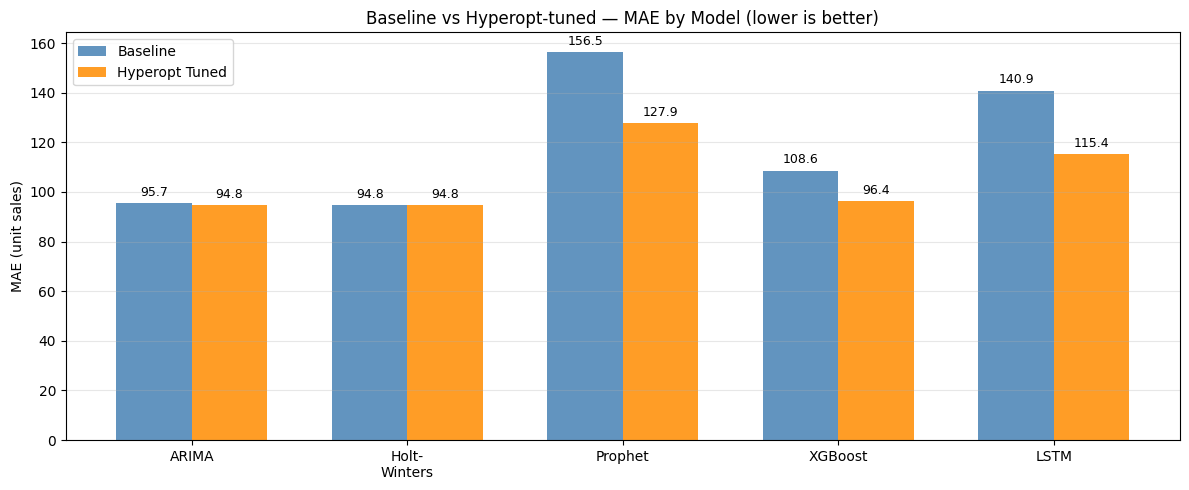

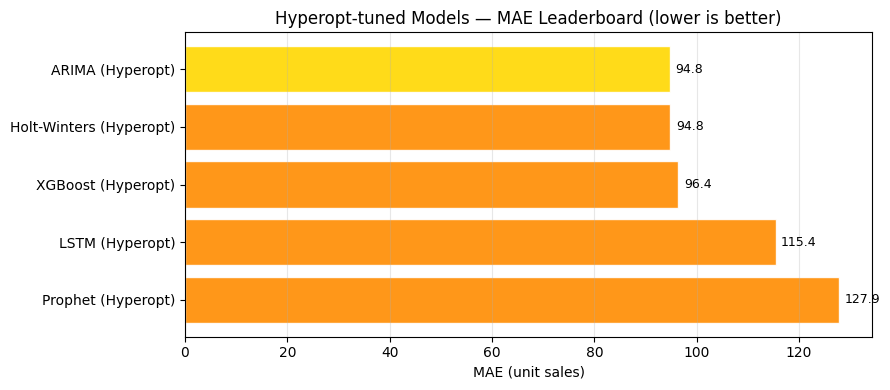


  Best Hyperopt-tuned model : ARIMA (Hyperopt)
  MAE  : 94.81
  RMSE : 142.67
  MAPE : 21.1%
  Bias : -6.90
  R²   : 0.395


In [29]:
# ── Baseline vs Hyperopt-tuned — text comparison ─────────────
df_all = pd.DataFrame(results).set_index('model')

_pairs = [
    ('ARIMA',               'ARIMA (Hyperopt)'),
    ('Holt-Winters',        'Holt-Winters (Hyperopt)'),
    ('Prophet',             'Prophet (Hyperopt)'),
    ('XGBoost (baseline)',  'XGBoost (Hyperopt)'),
    ('LSTM',                'LSTM (Hyperopt)'),
]

print("Baseline vs Hyperopt-tuned — MAE comparison")
print("=" * 72)
for base, tuned in _pairs:
    if base in df_all.index and tuned in df_all.index:
        b_mae = df_all.loc[base,  'MAE']
        t_mae = df_all.loc[tuned, 'MAE']
        delta = b_mae - t_mae
        tag   = "improved ↓" if delta > 0 else "no change / worse ↑"
        print(f"  {base:<25} {b_mae:>7.2f}  →  {tuned:<25} {t_mae:>7.2f}  ({delta:+.2f}  {tag})")

print()
print("Full leaderboard — all models sorted by MAE (best first):")
print(df_all[['MAE', 'RMSE', 'MAPE', 'R2']].sort_values('MAE').round(2).to_string())

# ── Bar chart 1: side-by-side baseline vs tuned MAE ──────────
_labels      = ['ARIMA', 'Holt-\nWinters', 'Prophet', 'XGBoost', 'LSTM']
_base_names  = ['ARIMA', 'Holt-Winters', 'Prophet', 'XGBoost (baseline)', 'LSTM']
_tuned_names = ['ARIMA (Hyperopt)', 'Holt-Winters (Hyperopt)', 'Prophet (Hyperopt)',
                'XGBoost (Hyperopt)', 'LSTM (Hyperopt)']

_base_maes  = [df_all.loc[n, 'MAE'] if n in df_all.index else 0 for n in _base_names]
_tuned_maes = [df_all.loc[n, 'MAE'] if n in df_all.index else 0 for n in _tuned_names]

x     = np.arange(len(_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, _base_maes,  width, label='Baseline',        color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, _tuned_maes, width, label='Hyperopt Tuned',  color='darkorange', alpha=0.85)
ax.bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(_labels)
ax.set_ylabel('MAE (unit sales)')
ax.set_title('Baseline vs Hyperopt-tuned — MAE by Model (lower is better)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── Bar chart 2: full leaderboard (all tuned models) ─────────
_tuned_only = df_all.loc[[n for n in _tuned_names if n in df_all.index], 'MAE'].sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['gold' if v == _tuned_only.min() else 'darkorange' for v in _tuned_only.values]
bars   = ax.barh(_tuned_only.index, _tuned_only.values, color=colors, alpha=0.9, edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=9)
ax.set_xlabel('MAE (unit sales)')
ax.set_title('Hyperopt-tuned Models — MAE Leaderboard (lower is better)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ── Best model summary ────────────────────────────────────────
_best_name = _tuned_only.idxmin()
_best_row  = df_all.loc[_best_name]

print()
print("=" * 50)
print(f"  Best Hyperopt-tuned model : {_best_name}")
print("=" * 50)
print(f"  MAE  : {_best_row['MAE']:.2f}")
print(f"  RMSE : {_best_row['RMSE']:.2f}")
print(f"  MAPE : {_best_row['MAPE']:.1f}%")
print(f"  Bias : {_best_row['Bias']:+.2f}")
print(f"  R²   : {_best_row['R2']:.3f}")

---
## Step 9 — Save the best model to disk

The model is saved to the `models/` folder inside your project.
`W3-streamlit.ipynb` will read this file — no need to retrain anything.

In [30]:
# ── Map model names to their trained objects ──────────────────
model_objects = {
    'ARIMA':              arima_fit,
    'Holt-Winters':       hw_fit,
    'Prophet':            prophet_model,
    'XGBoost (baseline)': xgb_model,
    'XGBoost (tuned)':    best_xgb,
    # 'LSTM':             lstm_model,   # uncomment if LSTM was run
}

print("Model objects mapped:")
for name in model_objects:
    print(f"  {name}")

Model objects mapped:
  ARIMA
  Holt-Winters
  Prophet
  XGBoost (baseline)
  XGBoost (tuned)


In [31]:
# ── Add Hyperopt-tuned models to model_objects ────────────────
model_objects.update({
    'ARIMA (Hyperopt)':        arima_tuned_fit,
    'Holt-Winters (Hyperopt)': hw_tuned_fit,
    'Prophet (Hyperopt)':      prophet_tuned_model,
    'XGBoost (Hyperopt)':      best_xgb_hyperopt,
    'LSTM (Hyperopt)':         lstm_tuned,
})

print("model_objects now contains:")
for name in model_objects:
    print(f"  {name}")

model_objects now contains:
  ARIMA
  Holt-Winters
  Prophet
  XGBoost (baseline)
  XGBoost (tuned)
  ARIMA (Hyperopt)
  Holt-Winters (Hyperopt)
  Prophet (Hyperopt)
  XGBoost (Hyperopt)
  LSTM (Hyperopt)


In [32]:
def save_best_model(model_name, model_objects, project_dir):                # define a function to save the best model to disk
    """
    Saves the best model to disk.
    Handles XGBoost, ARIMA, Holt-Winters, Prophet, and LSTM automatically.
    Returns the path where the model was saved.
    """
    models_dir = os.path.join(project_dir, 'models')                        # create a 'models' subfolder in the project directory
    os.makedirs(models_dir, exist_ok=True)                                  # create the directory if it doesn't exist 

    model_object = model_objects[model_name]                                # get the model object based on the name

    if 'LSTM' in model_name or 'RNN' in model_name:
        import torch
        save_path = os.path.join(models_dir, 'best_model.pt')
        torch.save(model_object.state_dict(), save_path)
    else:
        # XGBoost, ARIMA, Holt-Winters, Prophet — all save with joblib
        save_path = os.path.join(models_dir, 'best_model.pkl')
        joblib.dump(model_object, save_path)

    # Save the model name so the Streamlit app knows what type it is
    name_path = os.path.join(models_dir, 'best_model_name.txt')
    with open(name_path, 'w') as f:
        f.write(model_name)

    print(f"Model saved:      {save_path}")
    print(f"Model name saved: {name_path}")
    return save_path

print("save_best_model() defined.")

save_best_model() defined.


In [33]:
# ── Re-evaluate results table to include tuned model ─────────
df_results_final = pd.DataFrame(results).set_index('model')                 # create a DataFrame from the results list and set 'model' as the index
best_model_name  = df_results_final['MAE'].idxmin()                         # pick the best model name using the MAE, but you can change it
print(f"Best model: {best_model_name}")
print()

save_path = save_best_model(best_model_name, model_objects, PROJECT_DIR)    # save the best model to disk so it can be loaded by the Streamlit app

print()
print("Done. W3-streamlit.ipynb can now load this model.")

Best model: ARIMA (Hyperopt)

Model saved:      C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\models\best_model.pkl
Model name saved: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\models\best_model_name.txt

Done. W3-streamlit.ipynb can now load this model.


---
## Step 10 — Log experiments to MLflow

MLflow records every model's metrics so you can compare runs visually.

**Three things we log per run:**
- Parameters — the model type and settings used
- Metrics — MAE, RMSE, MAPE, Bias, R²
- Best model info — which model won and where it is saved

In [34]:
# ── Set up MLflow ────────────────────────────────────────────
mlflow.set_tracking_uri("file:///" + MLFLOW_PATH.replace("\\", "/"))    # set MLflow tracking URI to the mlruns folder in the project directory
mlflow.set_experiment("retail_sales_forecasting")                       # set the experiment name

print("MLflow tracking folder:", MLFLOW_PATH)
print("Experiment: retail_sales_forecasting")

MLflow tracking folder: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\mlruns
Experiment: retail_sales_forecasting


In [35]:
# ── Log every model as a separate run ────────────────────────
all_results = pd.DataFrame(results)                                     # create a DataFrame from the results list to log to MLflow
print(f"Logging {len(all_results)} runs to MLflow...")
print()

for _, row in all_results.iterrows():                                   # iterate over each row in the results DataFrame to log to MLflow
    with mlflow.start_run(run_name=row['model']):
        mlflow.log_param("model_type", row['model'])
        mlflow.log_metric("MAE",  row['MAE'])
        mlflow.log_metric("RMSE", row['RMSE'])
        mlflow.log_metric("MAPE", row['MAPE'])
        mlflow.log_metric("Bias", row['Bias'])
        mlflow.log_metric("R2",   row['R2'])
        print(f"  Logged: {row['model']}  |  MAE={row['MAE']:.2f}  R2={row['R2']:.3f}")

print()
print("All runs logged!")

Logging 11 runs to MLflow...

  Logged: ARIMA  |  MAE=95.65  R2=0.386
  Logged: Holt-Winters  |  MAE=94.83  R2=0.392
  Logged: Prophet  |  MAE=156.53  R2=-0.212
  Logged: XGBoost (baseline)  |  MAE=108.60  R2=0.279
  Logged: LSTM  |  MAE=140.88  R2=-0.006
  Logged: XGBoost (tuned)  |  MAE=96.30  R2=0.405
  Logged: ARIMA (Hyperopt)  |  MAE=94.81  R2=0.395
  Logged: Holt-Winters (Hyperopt)  |  MAE=94.83  R2=0.392
  Logged: Prophet (Hyperopt)  |  MAE=127.86  R2=0.009
  Logged: XGBoost (Hyperopt)  |  MAE=96.42  R2=0.385
  Logged: LSTM (Hyperopt)  |  MAE=115.40  R2=0.086

All runs logged!


In [36]:
# ── Log the best model run with full detail ───────────────────
with mlflow.start_run(run_name=f"BEST__{best_model_name}"):             # start a new MLflow run for the best model with a special name
    mlflow.log_param("best_model", best_model_name)
    mlflow.log_param("model_path", save_path)
    mlflow.log_metric("MAE",  df_results_final.loc[best_model_name, 'MAE'])
    mlflow.log_metric("RMSE", df_results_final.loc[best_model_name, 'RMSE'])
    mlflow.log_metric("MAPE", df_results_final.loc[best_model_name, 'MAPE'])
    mlflow.log_metric("Bias", df_results_final.loc[best_model_name, 'Bias'])
    mlflow.log_metric("R2",   df_results_final.loc[best_model_name, 'R2'])

    # Log XGBoost tuning params if it was the best model
    if 'XGBoost' in best_model_name and 'tuned' in best_model_name:     # if the best model is the tuned XGBoost, log the best hyperparameters
        mlflow.log_params(search.best_params_)

    print(f"Best model run logged: BEST__{best_model_name}")
    print(f"MAE:  {df_results_final.loc[best_model_name, 'MAE']}")
    print(f"RMSE: {df_results_final.loc[best_model_name, 'RMSE']}")
    print(f"R²:   {df_results_final.loc[best_model_name, 'R2']}")

Best model run logged: BEST__ARIMA (Hyperopt)
MAE:  94.81
RMSE: 142.67
R²:   0.395


---
## Summary

| Step | What we did |
|---|---|
| Data cleaning | Filled missing dates and values |
| 5 models trained | ARIMA, Holt-Winters, Prophet, XGBoost, LSTM (optional) |
| Evaluation | MAE, RMSE, MAPE, Bias, R², Training time |
| Hyperparameter tuning | RandomizedSearchCV on XGBoost |
| Model saved | `models/best_model.pkl` in your project folder |
| MLflow logged | All runs recorded in `mlruns/` folder |

---
### Ready for W3-streamlit.ipynb

The following files were created in `PROJECT_DIR`:
- `models/best_model.pkl` — the trained model
- `models/best_model_name.txt` — the name of the best model

> **GitHub commit:**
> Add `W3-mlflow.ipynb` with message: `"W3: pipeline, 5 models, tuning, MLflow"`